In [1]:
# 1. IMPORT LIBRARIES 
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import io
from scipy.fftpack import dct, idct

In [2]:
#  2. LOAD AND DISPLAY IMAGE 
img_url = 'https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png'
img = io.imread(img_url)

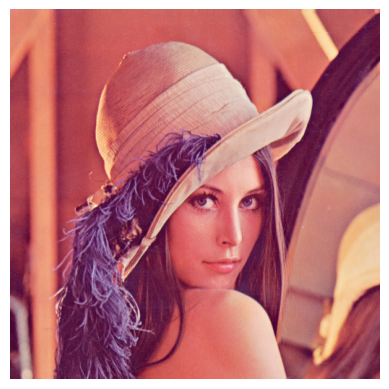

In [3]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
# 3. CONVERT RGB TO YCbCr 
img_ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)

In [5]:
# 4. Split the image into Y, Cr, Cb
Y, Cr, Cb = cv2.split(img_ycbcr)

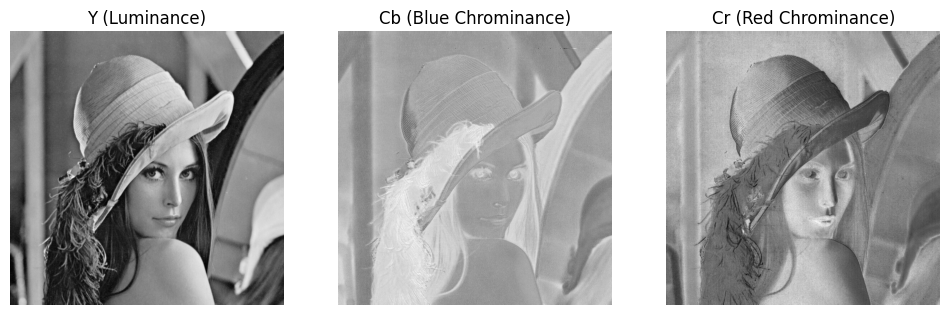

In [6]:
# Visualize channels
plt.figure(figsize=(12, 4))
for i, (channel, title) in enumerate(zip([Y, Cb, Cr], ["Y (Luminance)", "Cb (Blue Chrominance)", "Cr (Red Chrominance)"])):
    plt.subplot(1, 3, i+1)
    plt.imshow(channel, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()

In [7]:
# 5. CHROMA SUBSAMPLING (4:2:0)
def chroma_subsample(channel):
    h, w = channel.shape
    h, w = h - h % 2, w - w % 2

    channel = channel[:h, :w]

    subsampled = np.zeros((h // 2, w // 2), dtype=np.float32)

    for i in range(0, h, 2):
        for j in range(0, w, 2):
            top_left     = channel[i, j]
            top_right    = channel[i, j+1]
            bottom_left  = channel[i+1, j]
            bottom_right = channel[i+1, j+1]

            average = (top_left + top_right + bottom_left + bottom_right) / 4

            subsampled[i//2, j//2] = average

    return subsampled.astype(np.uint8)

In [8]:
Cb_sub = chroma_subsample(Cb)
Cr_sub = chroma_subsample(Cr)

C:\Users\User\AppData\Local\Temp\ipykernel_10748\657463477.py:17: RuntimeWarning: overflow encountered in scalar add
  average = (top_left + top_right + bottom_left + bottom_right) / 4


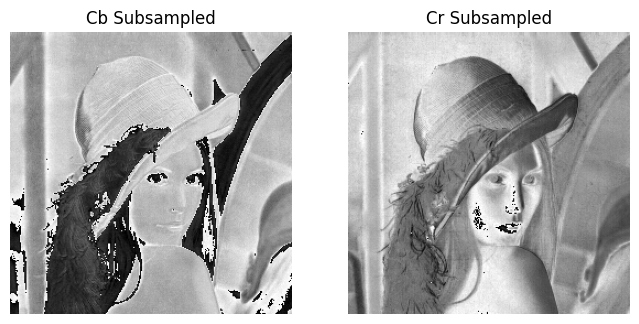

In [9]:
# Visualize subsampled channels
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(Cb_sub, cmap='gray')
plt.title("Cb Subsampled")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(Cr_sub, cmap='gray')
plt.title("Cr Subsampled")
plt.axis('off')
plt.show()

In [10]:
# 6. 8x8 BLOCK DIVISION (ON Y ONLY)
def split_into_blocks(channel, block_size=8):
    h, w = channel.shape
    h_trim = h - (h % block_size)
    w_trim = w - (w % block_size)
    channel = channel[:h_trim, :w_trim]

    blocks = []
    for i in range(0, h_trim, block_size):
        row_blocks = []
        for j in range(0, w_trim, block_size):
            block = channel[i:i+block_size, j:j+block_size]
            row_blocks.append(block)
        blocks.append(row_blocks)

    return np.array(blocks)

In [11]:
blocks = split_into_blocks(Y)

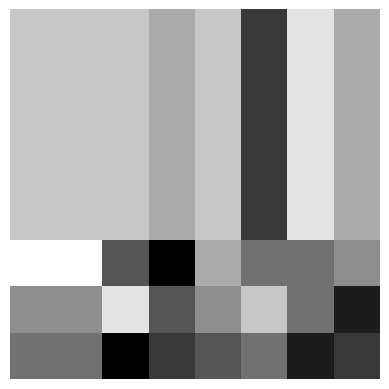

In [12]:
plt.imshow(blocks[0, 0], cmap='gray')
plt.axis('off')
plt.show()

In [13]:
# 7. DCT 
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

In [14]:
dct_block = dct2(blocks[0, 0] - 128)

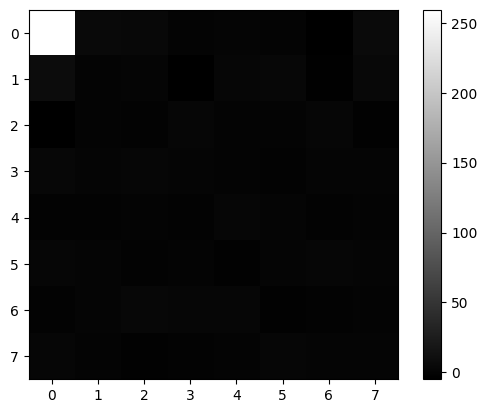

In [15]:
plt.imshow(dct_block, cmap='gray')
plt.colorbar()
plt.show()

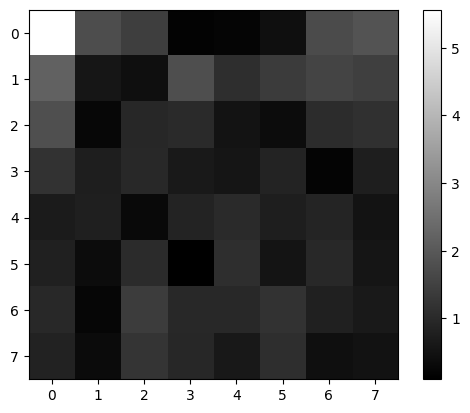

In [16]:
plt.imshow(np.log(np.abs(dct_block) + 1), cmap='gray')
plt.colorbar()
plt.show()

In [17]:
# 8. Quantization
Q10 = np.array([
    [80, 60, 50, 80,120,200,255,255],
    [60, 60,70,100,150,255,255,255],
    [70,65,80,120,200,255,255,255],
    [70,85,110,145,255,255,255,255],
    [90,110,185,255,255,255,255,255],
    [120,175,255,255,255,255,255,255],
    [245,255,255,255,255,255,255,255],
    [255,255,255,255,255,255,255,255]])

Q75 =   np.array([
    [ 8,  6,  5,  8, 12, 20, 26, 31],
    [ 6,  6,  7, 10, 13, 29, 30, 28],
    [ 7,  7,  8, 12, 20, 29, 35, 28],
    [ 7,  9, 11, 15, 26, 44, 40, 31],
    [ 9, 11, 19, 28, 34, 55, 52, 39],
    [12, 18, 28, 32, 41, 52, 57, 46],
    [25, 32, 39, 44, 52, 61, 60, 51],
    [36, 46, 48, 49, 56, 50, 52, 50]])

Q90 = np.array([
    [ 1,  2,  2,  3,  5,  8, 10, 12],
    [ 2,  2,  3,  4,  5, 12, 12, 11],
    [ 3,  3,  3,  5,  8, 11, 14, 11],
    [ 3,  4,  6,  8, 10, 17, 16, 12],
    [ 4,  6, 10, 11, 13, 16, 18, 14],
    [ 7, 11, 12, 13, 16, 19, 19, 16],
    [10, 14, 15, 16, 18, 20, 20, 17],
    [14, 16, 17, 18, 19, 17, 17, 17]
])

quantized_block = dct_block/Q10

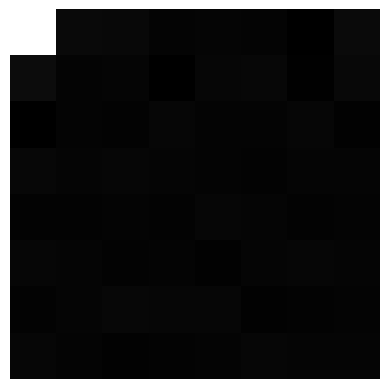

In [18]:
plt.imshow(dct_block, cmap='gray')
plt.axis('off')
plt.show()

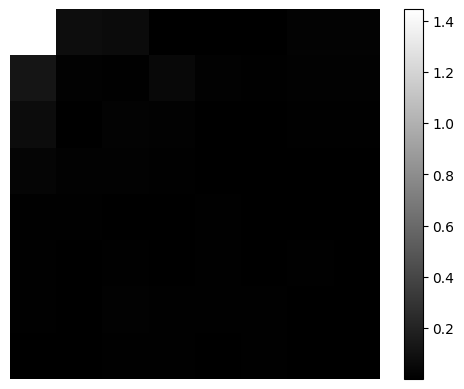

In [19]:
plt.imshow(np.log(np.abs(quantized_block) + 1), cmap='gray')
plt.colorbar()
plt.axis('off')
plt.show()

In [20]:
# 9. Dequantization and IDCT
dequantized_block = quantized_block * Q10

In [21]:
def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

In [22]:
reconstructed_image = idct2(dequantized_block) + 128

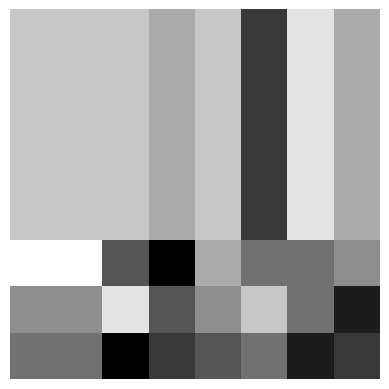

In [23]:
plt.imshow(reconstructed_image, cmap='gray')
plt.axis('off')
plt.show()

In [24]:
import numpy as np
import cv2
from scipy.fftpack import dct, idct

# 8x8 DCT and IDCT
def dct2(block):
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block):
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# Split into 8x8 blocks
def split_into_blocks(channel):
    h, w = channel.shape
    assert h % 8 == 0 and w % 8 == 0, "Image must be divisible by 8"
    blocks = []
    for i in range(0, h, 8):
        for j in range(0, w, 8):
            blocks.append(channel[i:i+8, j:j+8])
    return blocks

# JPEG-like compression
def jpeg_compress(img, Q, subsample=True):
    # Convert RGB to YCrCb
    img_ycbcr = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    Y, Cr, Cb = cv2.split(img_ycbcr)

    # Ensure image is divisible by 8
    def pad_image(channel):
        h, w = channel.shape
        pad_h = (8 - h % 8) % 8
        pad_w = (8 - w % 8) % 8
        return np.pad(channel, ((0, pad_h), (0, pad_w)), mode='constant')

    Y = pad_image(Y)
    Cr = pad_image(Cr)
    Cb = pad_image(Cb)

    if subsample:
        Cr = cv2.resize(Cr, (Cr.shape[1] // 2, Cr.shape[0] // 2), interpolation=cv2.INTER_LINEAR)
        Cb = cv2.resize(Cb, (Cb.shape[1] // 2, Cb.shape[0] // 2), interpolation=cv2.INTER_LINEAR)

    def compress_channel(channel, Q):
        h, w = channel.shape
        blocks = split_into_blocks(channel)
        dct_blocks = [dct2(block) for block in blocks]
        quant_blocks = [(dct_block / Q) for dct_block in dct_blocks]
        dequant_blocks = [quant * Q for quant in quant_blocks]
        idct_blocks = [idct2(block) for block in dequant_blocks]

        # Reconstruct the image
        out = np.zeros((h, w))
        idx = 0
        for i in range(0, h, 8):
            for j in range(0, w, 8):
                out[i:i+8, j:j+8] = idct_blocks[idx]
                idx += 1
        return np.clip(out, 0, 255).astype(np.uint8)

    Y_comp = compress_channel(Y, Q)

    # Upsample if chroma was subsampled
    if subsample:
        Cr = cv2.resize(Cr, (Y.shape[1], Y.shape[0]), interpolation=cv2.INTER_LINEAR)
        Cb = cv2.resize(Cb, (Y.shape[1], Y.shape[0]), interpolation=cv2.INTER_LINEAR)

    # Merge and convert back to RGB
    ycbcr_merged = cv2.merge([Y_comp, Cr, Cb])
    rgb_reconstructed = cv2.cvtColor(ycbcr_merged, cv2.COLOR_YCrCb2RGB)

    return rgb_reconstructed


In [25]:
# COMPRESS THE FULL IMAGE using the jpeg_compress function
compressed_img10 = jpeg_compress(img, Q10, subsample=True)

In [26]:
# COMPRESS THE FULL IMAGE using the jpeg_compress function
compressed_img75 = jpeg_compress(img, Q75, subsample=True)

In [27]:
# COMPRESS THE FULL IMAGE using the jpeg_compress function
compressed_img90 = jpeg_compress(img, Q90, subsample=True)

In [28]:
# 11. PSNR CALCULATION
def psnr(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

In [29]:
psnr_val10 = psnr(img.astype(np.float32), compressed_img10.astype(np.float32))

In [30]:
psnr_val75 = psnr(img.astype(np.float32), compressed_img75.astype(np.float32))

In [31]:
psnr_val90 = psnr(img.astype(np.float32), compressed_img90.astype(np.float32))

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

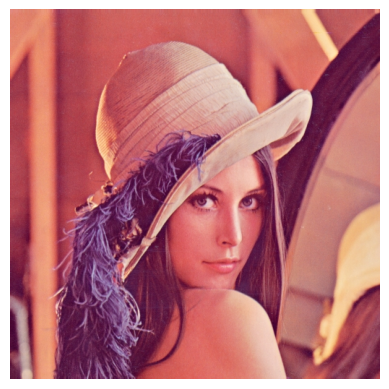

In [32]:
plt.imshow(compressed_img10)
plt.axis('off')

In [33]:
print(f"The psnr value for 10 is: {psnr_val10} dB")

The psnr value for 10 is: 37.53105926513672 dB


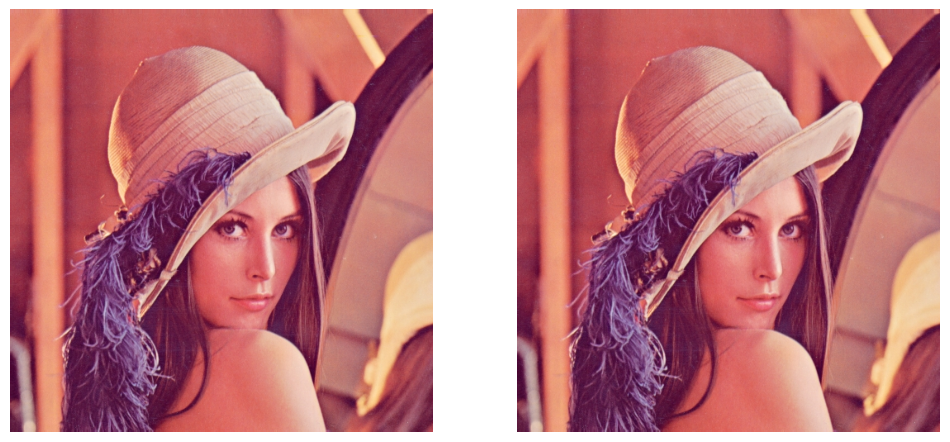

In [34]:
# give subplots of 2 images for compressed 75 and 90
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)    
plt.imshow(compressed_img75)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(compressed_img90)
plt.axis('off')
plt.show()

In [35]:
print(f"The psnr value 75 and 90 is: {psnr_val75} dB, {psnr_val90} dB")

The psnr value 75 and 90 is: 37.53240966796875 dB, 37.532379150390625 dB


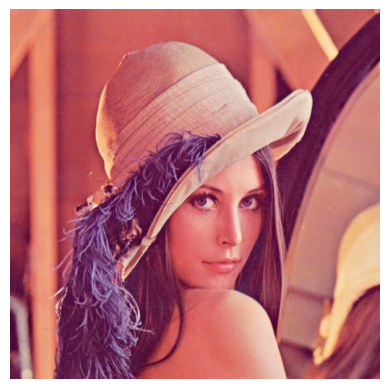

PSNR with OpenCV JPEG:  34.76601


In [36]:
# 12. BONUS TASKS 
# a. Try different Q matrices
# b. Set subsample=False in jpeg_compress() to disable chroma subsampling
# c. Compare OpenCV JPEG
_, encoded = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR), [int(cv2.IMWRITE_JPEG_QUALITY), 90])
decoded = cv2.imdecode(encoded, 1)
decoded_rgb = cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

plt.imshow(decoded_rgb)
plt.axis('off')
plt.show()
print("PSNR with OpenCV JPEG: ", psnr(img.astype(np.float32), decoded_rgb.astype(np.float32)))